<a href="https://colab.research.google.com/github/abhishekanand04/ML-Adv-Supervised-Alogorithms/blob/mladv/kmeans%2B%2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
!wget "https://drive.google.com/uc?export=download&id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W" -O E-commerce.csv

--2025-06-04 17:03:12--  https://drive.google.com/uc?export=download&id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W
Resolving drive.google.com (drive.google.com)... 172.253.63.139, 172.253.63.102, 172.253.63.138, ...
Connecting to drive.google.com (drive.google.com)|172.253.63.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W&export=download [following]
--2025-06-04 17:03:13--  https://drive.usercontent.google.com/download?id=1lEccW5Y5_2z00VRtLGOAJOAU6YA9fl6W&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.167.132, 2607:f8b0:4004:c1d::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.167.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 139827 (137K) [application/octet-stream]
Saving to: ‘E-commerce.csv’

E-commerce.csv      100%[===================>] 136.55K  --.-KB/

In [ ]:
df = pd.read_csv('./E-commerce.csv')
df.head()

,ID,n_clicks,n_visits,amount_spent,amount_discount,days_since_registration,profile_information
0,1476,130,65,213.905831,31.600751,233,235
1,1535,543,46,639.223004,5.689175,228,170
2,1807,520,102,1157.402763,844.321606,247,409
3,1727,702,83,1195.903634,850.041757,148,200
4,1324,221,84,180.754616,64.283300,243,259


In [ ]:
X=df.drop("ID",axis=1)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X)
X=scaler.transform(X)

In [ ]:
X.shape

(2500, 6)

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(2)
components_pca = pca.fit_transform(X)

In [ ]:
def viz_clusters(clusters):
    plt.scatter(clusters['X1'], clusters['X2'], c=clusters['label'], s = 40)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title('Visualizing Clusters')



In [ ]:
from sklearn.cluster import KMeans

In [ ]:
kmeans_iter1 = KMeans(n_clusters=3, init="random", n_init=1,
                     algorithm="lloyd", random_state=0)
kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1,
                     algorithm="lloyd", random_state=0)
kmeans_iter3 = KMeans(n_clusters=8, init="random", n_init=1,
                     algorithm="lloyd", random_state=0)
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

KMeans(init='random', n_init=1, random_state=0)

In [ ]:
clusters_1 = pd.DataFrame(components_pca, columns=['X1', 'X2'])
clusters_1['label'] = kmeans_iter1.labels_


clusters_2 = pd.DataFrame(components_pca, columns=['X1', 'X2'])
clusters_2['label'] = kmeans_iter2.labels_


clusters_3 = pd.DataFrame(components_pca, columns=['X1', 'X2'])
clusters_3['label'] = kmeans_iter3.labels_


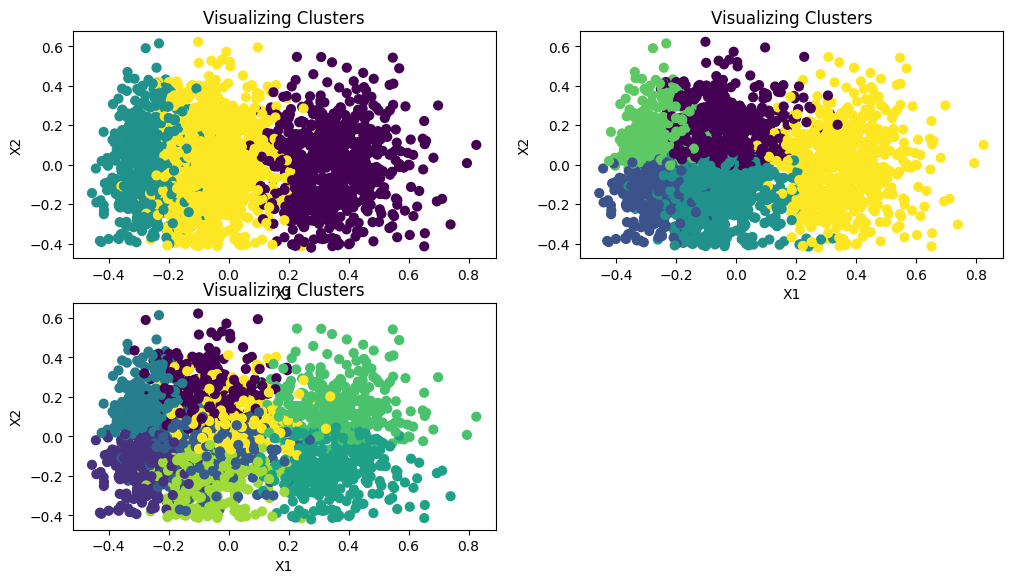

In [ ]:
plt.figure(figsize=(12,10))

plt.subplot(321)
viz_clusters(clusters_1)

plt.subplot(322)
viz_clusters(clusters_2)

plt.subplot(323)
viz_clusters(clusters_3)

In [ ]:
kmeans_iter1.inertia_  #3

280.16509626121064

In [ ]:
kmeans_iter2.inertia_ #5

234.85005987694063

In [ ]:
kmeans_iter3.inertia_ #8

193.00182851000528

In [ ]:
# Inertia = Within Cluster Sum of Squares
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X)
                for k in range(1, 10)]

inertias = [model.inertia_ for model in kmeans_per_k]

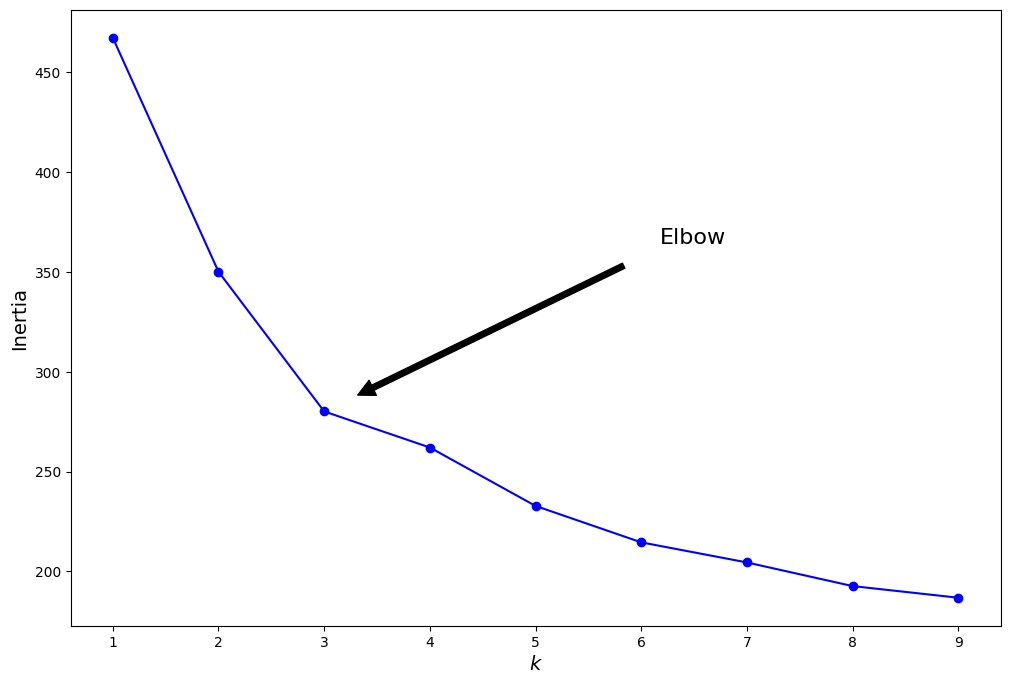

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inertia", fontsize=14)
plt.annotate('Elbow',
             xy=(3, inertias[2]),
             xytext=(0.55, 0.55),
             textcoords='figure fraction',
             fontsize=16,
             arrowprops=dict(facecolor='black', shrink=0.1)
            )
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

k = 4 ## arbitrary value
kmeans = KMeans(n_clusters=k,random_state = 42)
kmeans.fit(X)

KMeans(n_clusters=4, random_state=42)

In [ ]:
## silhouette score for 4 clusters
silhouette_score(X, kmeans.labels_)

np.float64(0.24019904847942408)

In [ ]:
## plot for different values of K
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

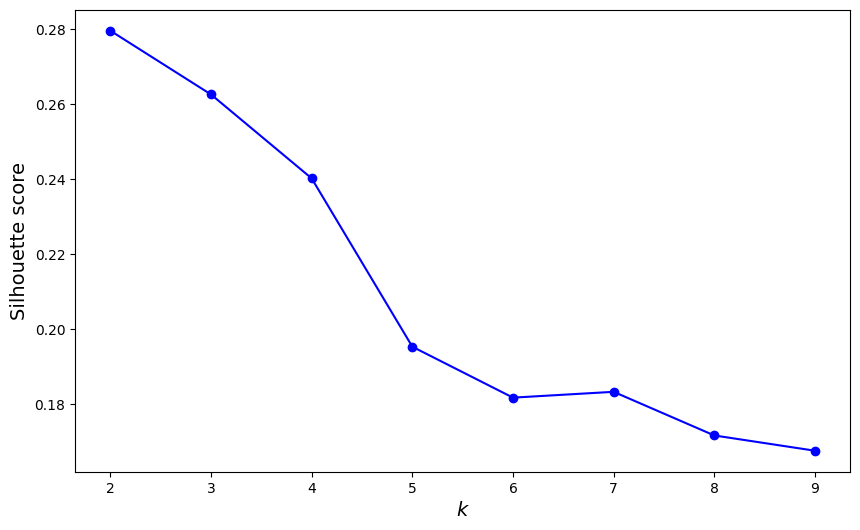

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.show()

### k-means from scratch

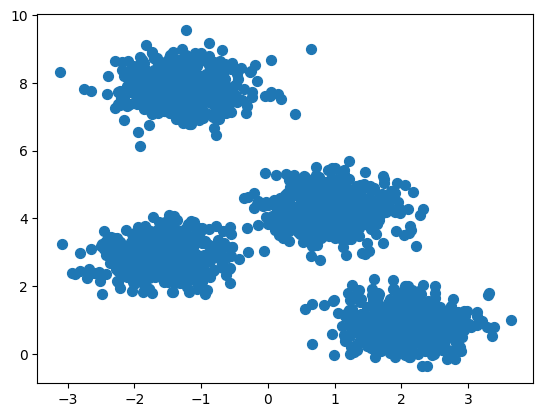

In [ ]:
from sklearn.datasets import make_blobs

# Generate synthetic data
X, y =make_blobs(n_samples=2000, centers=4, n_features=2,random_state=0, cluster_std=0.5)
 #make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);
plt.show()

In [ ]:
X.shape

(2000, 2)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
K = 3
random_indices = np.random.permutation(X.shape[0])
centroids = X[random_indices[:K]]

In [ ]:
random_indices[:K]

array([1680,  902,  790])

In [ ]:
centroids

array([[ 1.742489  ,  1.39373207],
       [-1.14836346,  8.30613397],
       [ 1.95509078,  0.0406406 ]])

In [ ]:
# Function to initialize centroids
def initialize_centroids(X, K):
    np.random.seed(42)  # For reproducibility
    random_indices = np.random.permutation(X.shape[0])
    centroids = X[random_indices[:K]]
    return centroids

In [ ]:
    distances = np.array([]).reshape(len(X),0)
    for centroid in centroids:
        distance = (((X - centroid)**2).sum(axis=1)**0.5).reshape(-1,1)
        distances = np.hstack([distances, distance])

In [ ]:
distances

array([[2.89274406, 5.98263327, 3.73227167],
       [3.03425735, 4.480024  , 4.3518861 ],
       [0.6078424 , 8.06662514, 0.92751775],
       ...,
       [2.89885411, 4.63927579, 4.2638076 ],
       [3.38984682, 5.00389313, 4.44129126],
       [2.86124488, 4.91961155, 4.22426173]])

In [ ]:
 clusters = np.argmin(distances, axis=1)
 clusters

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
def assign_clusters(X, centroids):

    distances = np.array([]).reshape(len(X),0)
    for centroid in centroids:
        distance = (((X - centroid)**2).sum(axis=1)**0.5).reshape(-1,1)
        distances = np.hstack([distances, distance])
    clusters = np.argmin(distances, axis=1)
    return clusters


In [ ]:
 centroid_mean = []
 for k in range(K):
  centroid_mean.append(X[clusters == k].mean(axis=0))

In [ ]:
centroid_mean

[array([0.21108956, 3.00170881]),
 array([-1.16582816,  7.68228912]),
 array([2.11566908, 0.4491154 ])]

In [ ]:
# Function to update centroids
def update_centroids(X, clusters, K):
    new_centroids = np.array([X[clusters == k].mean(axis=0) for k in range(K)])
    return new_centroids

In [ ]:
def display_results(X,clusters,centroids):
  # Plot the results
  plt.scatter(X[:, 0], X[:, 1], c=clusters, s=50, cmap='viridis')
  plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='red', marker='X')
  plt.show()


In [ ]:
# K-Means algorithm
def k_means(X, K, max_iters=100, tol=1e-4):
    centroids = initialize_centroids(X, K)
    for i in range(max_iters):
        clusters = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, clusters, K)

        # Check for convergence
        if np.all(np.abs(new_centroids - centroids) < tol):
            break

        centroids = new_centroids
        display_results(X,clusters,centroids)
    return centroids, clusters

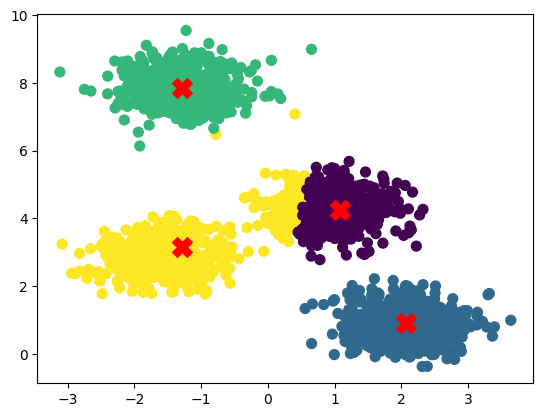

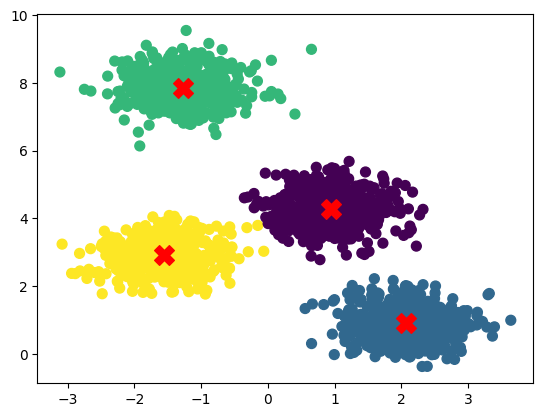

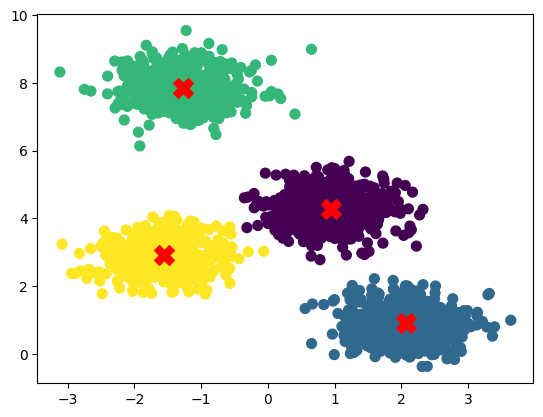

In [ ]:
K = 4
centroids, clusters = k_means(X, K)

In [ ]:
for i in range(8):
 c2 = np.random.choice([0,1,2,3,4],p=[0.30,0.2,0.28,0.15,0.07])
 print(c2)

0
2
4
0
2
1
3
0
